# CES Benchmark (Complex Exponential Smoothing)

Parallel evaluation of every available Python implementation of CES on the M1, M3
and Tourism competition series, using the same harness and settings as the ETS
benchmark: fit on `series.x`, forecast `series.h` steps, score against
`series.xx`.

**Implementations found.** Only two exist:

- **smooth** — `AutoCES` (seasonality selected by AICc among `none`, `simple`,
  `partial`, `full`) plus the four fixed-seasonality members it chooses among.
- **statsforecast** — `AutoCES` (Nixtla).

`sktime`'s `StatsForecastAutoCES` is a thin adapter around the statsforecast
routine rather than an independent implementation; it is included so its row can
be read as a harness check (it should reproduce the statsforecast row exactly).
`skforecast` and `aeon` ship no CES at all.

**Metrics:** RMSSE, SAME, computational time — same definitions as the ETS
notebook.

In [1]:
import numpy as np
import pandas as pd
import multiprocessing
import warnings
warnings.filterwarnings('ignore')

from fcompdata import M1, M3, Tourism

In [2]:
# Which implementations are actually available here
from importlib.metadata import version as pkg_version
import sys

print(f"python {sys.version.split()[0]}")
for _p in ('numpy', 'pandas'):
    print(f"{_p} v{pkg_version(_p)}")
print()

available = {}

try:
    from smooth import AutoCES, CES  # noqa: F401
    available['smooth'] = True
    print(f"smooth v{pkg_version('smooth')}: AutoCES + CES")
except ImportError as e:
    available['smooth'] = False
    print(f"smooth: not available ({e})")

try:
    from statsforecast.models import AutoCES as _SFAutoCES  # noqa: F401
    available['statsforecast'] = True
    print(f"statsforecast v{pkg_version('statsforecast')}: AutoCES")
except ImportError as e:
    available['statsforecast'] = False
    print(f"statsforecast: not available ({e})")

try:
    from sktime.forecasting.statsforecast import StatsForecastAutoCES  # noqa: F401
    available['sktime'] = True
    print(f"sktime v{pkg_version('sktime')}: StatsForecastAutoCES (wraps statsforecast)")
except ImportError as e:
    available['sktime'] = False
    print(f"sktime: no CES ({e})")

# skforecast and aeon: confirm there is no CES to benchmark
import pkgutil, importlib
for _p in ('skforecast', 'aeon'):
    try:
        _m = importlib.import_module(_p)
        _hits = [n.name for n in pkgutil.walk_packages(_m.__path__, _p + '.')
                 if 'ces' in n.name.rsplit('.', 1)[-1].lower()]
        print(f"{_p} v{pkg_version(_p)}: no CES implementation "
              f"({'no modules match' if not _hits else 'only ' + ', '.join(_hits[:3])})")
    except ImportError:
        print(f"{_p}: not installed")

python 3.14.4
numpy v2.3.5
pandas v2.3.3



smooth v1.0.7: AutoCES + CES


statsforecast v2.1.1: AutoCES


sktime v1.0.1: StatsForecastAutoCES (wraps statsforecast)


skforecast v0.23.0: no CES implementation (only skforecast.preprocessing, skforecast.preprocessing._preprocessing)


aeon v1.5.0: no CES implementation (only aeon.distances, aeon.distances.tests.test_distances, aeon.distances.tests.test_miscellaneous_distances)


## Error Metrics

Identical to the ETS notebook.

In [3]:
def RMSSE(holdout, forecast, actuals):
    """Root Mean Squared Scaled Error."""
    holdout = np.asarray(holdout)
    forecast = np.asarray(forecast)
    actuals = np.asarray(actuals)

    mse = np.mean((holdout - forecast) ** 2)
    scale = np.mean(np.diff(actuals) ** 2)

    if scale == 0:
        return np.nan

    return np.sqrt(mse / scale)

def SAME(holdout, forecast, actuals):
    """Scaled Absolute Mean Error."""
    holdout = np.asarray(holdout)
    forecast = np.asarray(forecast)
    actuals = np.asarray(actuals)

    ame = np.abs(np.mean(holdout - forecast))
    scale = np.mean(np.abs(np.diff(actuals)))

    if scale == 0:
        return np.nan

    return ame / scale

## Load Datasets

In [4]:
datasets = []
for idx in M1.keys():
    datasets.append(M1[idx])
for idx in M3.keys():
    datasets.append(M3[idx])
for idx in Tourism.keys():
    datasets.append(Tourism[idx])

print(f"Total series: {len(datasets)}")
print(f"M1: {len(M1)} series")
print(f"M3: {len(M3)} series")
print(f"Tourism: {len(Tourism)} series")

Total series: 5315
M1: 1001 series
M3: 3003 series
Tourism: 1311 series


## Define Methods

`smooth`'s `AutoCES` is run under the three initialisation methods, mirroring the
`ADAM ETS Back/Opt/Two` rows of the ETS notebook. The four fixed-seasonality
rows are the members `AutoCES` selects among — the CES analogue of the ETS
notebook's `ES XXX / ZZZ / FFF / SXS` pool rows. On yearly data a seasonal CES
has no seasonal lag, so those rows fall back to `seasonality="none"`, the same
way the ETS notebook drops the seasonal letter when `period == 1`.

In [5]:
from run_ces_benchmark import METHODS

methods_names = [m[0] for m in METHODS]
methods_number = len(methods_names)
dataset_length = len(datasets)

print(f"Methods: {methods_number}")
print(f"Datasets: {dataset_length}\n")
for name, pkg, cfg in METHODS:
    detail = ", ".join(f"{k}={v}" for k, v in cfg.items()) or "defaults"
    print(f"  {name:24s} [{pkg}]  {detail}")

Methods: 9
Datasets: 5315

  CES Back                 [smooth-auto]  initial=backcasting
  CES Opt                  [smooth-auto]  initial=optimal
  CES Two                  [smooth-auto]  initial=two-stage
  CES none                 [smooth-fixed]  seasonality=none, initial=backcasting
  CES simple               [smooth-fixed]  seasonality=simple, initial=backcasting
  CES partial              [smooth-fixed]  seasonality=partial, initial=backcasting
  CES full                 [smooth-fixed]  seasonality=full, initial=backcasting
  statsforecast AutoCES    [statsforecast]  defaults
  sktime AutoCES           [sktime]  defaults


## Run Evaluation

The heavy run lives in `run_ces_benchmark.py`, which fans the
`methods x series` grid out over a process pool (same structure as
`run_dist_benchmark.py`). Set `BENCH_RERUN_CES=1` to recompute; otherwise the
saved results are loaded.

In [6]:
import os, glob, subprocess, sys

print(f"Available CPU cores: {multiprocessing.cpu_count()}")

if os.environ.get("BENCH_RERUN_CES", "0") == "1":
    env = dict(os.environ,
               BENCH_WORKERS=str(min(30, multiprocessing.cpu_count())))
    subprocess.run([sys.executable, "run_ces_benchmark.py"], check=True, env=env)

_files = sorted(glob.glob("*-benchmark-ces.npy"))
assert _files, "no *-benchmark-ces.npy found; run run_ces_benchmark.py first"
test_results = np.load(_files[-1])
print("loaded", _files[-1], "shape", test_results.shape)
assert test_results.shape[:2] == (methods_number, dataset_length)

print("\nPer-method summary:")
for j, method in enumerate(methods_names):
    print(f"  {method:24s}: RMSSE={np.nanmean(test_results[j, :, 0]):.4f}, "
          f"SAME={np.nanmean(test_results[j, :, 1]):.4f}, "
          f"Time={np.nanmean(test_results[j, :, 2]):.3f}s, "
          f"Failed={int(np.sum(np.isnan(test_results[j, :, 0])))}")

Available CPU cores: 32
loaded 2026-08-22-benchmark-ces.npy shape (9, 5315, 3)

Per-method summary:
  CES Back                : RMSSE=2.0997, SAME=2.0227, Time=0.257s, Failed=0
  CES Opt                 : RMSSE=2.1174, SAME=2.0474, Time=1.017s, Failed=0
  CES Two                 : RMSSE=2.1216, SAME=2.0525, Time=1.239s, Failed=0
  CES none                : RMSSE=2.1569, SAME=2.1400, Time=0.028s, Failed=0
  CES simple              : RMSSE=2.4058, SAME=2.3350, Time=0.063s, Failed=0
  CES partial             : RMSSE=2.0987, SAME=2.0089, Time=0.080s, Failed=0
  CES full                : RMSSE=2.1037, SAME=2.0099, Time=0.099s, Failed=0
  statsforecast AutoCES   : RMSSE=1.9573, SAME=1.9978, Time=0.007s, Failed=0
  sktime AutoCES          : RMSSE=1.9573, SAME=1.9978, Time=0.015s, Failed=0


## Results Summary

In [7]:
def _summary(metric_idx, label, time_col='Mean Time (s)'):
    frame = pd.DataFrame({
        'Method': methods_names,
        'Min': [np.nanmin(test_results[j, :, metric_idx]) for j in range(methods_number)],
        'Q1': [np.nanquantile(test_results[j, :, metric_idx], 0.25) for j in range(methods_number)],
        'Med': [np.nanmedian(test_results[j, :, metric_idx]) for j in range(methods_number)],
        'Q3': [np.nanquantile(test_results[j, :, metric_idx], 0.75) for j in range(methods_number)],
        'Max': [np.nanmax(test_results[j, :, metric_idx]) for j in range(methods_number)],
        'Mean': [np.nanmean(test_results[j, :, metric_idx]) for j in range(methods_number)],
        time_col: [np.nanmean(test_results[j, :, 2]) for j in range(methods_number)],
        'Failed': [int(np.sum(np.isnan(test_results[j, :, metric_idx]))) for j in range(methods_number)],
    })
    print("\n" + "=" * 95)
    print(f"EVALUATION RESULTS for {label} (All Series)")
    print("=" * 95)
    print(frame.to_string(index=False))
    return frame

summary_rmsse = _summary(0, 'RMSSE')


EVALUATION RESULTS for RMSSE (All Series)
               Method      Min       Q1      Med       Q3       Max     Mean  Mean Time (s)  Failed
             CES Back 0.025953 0.836424 1.376174 2.436144 51.057051 2.099664       0.257178       0
              CES Opt 0.024852 0.853367 1.397611 2.405314 49.720240 2.117389       1.017100       0
              CES Two 0.024856 0.852383 1.392827 2.431502 49.404629 2.121648       1.239326       0
             CES none 0.025953 0.887686 1.424903 2.506811 51.057051 2.156925       0.028311       0
           CES simple 0.044957 0.942435 1.556609 2.776164 51.057051 2.405842       0.062755       0
          CES partial 0.050789 0.855111 1.387697 2.447807 51.057051 2.098706       0.080380       0
             CES full 0.047692 0.850830 1.402327 2.476836 51.057051 2.103662       0.098970       0
statsforecast AutoCES 0.044922 0.678056 1.167207 2.286125 50.624710 1.957299       0.006907       0
       sktime AutoCES 0.044922 0.678056 1.167207 2.286125

In [8]:
summary_same = _summary(1, 'SAME')


EVALUATION RESULTS for SAME (All Series)
               Method      Min       Q1      Med       Q3       Max     Mean  Mean Time (s)  Failed
             CES Back 0.000178 0.387880 1.020451 2.433503 54.902623 2.022742       0.257178       0
              CES Opt 0.000316 0.404251 1.030406 2.445831 54.893002 2.047382       1.017100       0
              CES Two 0.000363 0.418325 1.039318 2.470256 54.889712 2.052463       1.239326       0
             CES none 0.000128 0.455377 1.190082 2.601363 54.902623 2.140024       0.028311       0
           CES simple 0.000028 0.435425 1.111250 2.747304 54.902623 2.334975       0.062755       0
          CES partial 0.000178 0.382842 1.017341 2.458121 54.902623 2.008880       0.080380       0
             CES full 0.000006 0.388451 1.011130 2.462464 54.902623 2.009944       0.098970       0
statsforecast AutoCES 0.000385 0.370623 1.000912 2.399531 54.892894 1.997793       0.006907       0
       sktime AutoCES 0.000385 0.370623 1.000912 2.399531 

In [9]:
summary_time = pd.DataFrame({
    'Method': methods_names,
    'Min': [np.nanmin(test_results[j, :, 2]) for j in range(methods_number)],
    'Q1': [np.nanquantile(test_results[j, :, 2], 0.25) for j in range(methods_number)],
    'Med': [np.nanmedian(test_results[j, :, 2]) for j in range(methods_number)],
    'Q3': [np.nanquantile(test_results[j, :, 2], 0.75) for j in range(methods_number)],
    'Max': [np.nanmax(test_results[j, :, 2]) for j in range(methods_number)],
    'Mean': [np.nanmean(test_results[j, :, 2]) for j in range(methods_number)],
    'Total (min)': [np.nansum(test_results[j, :, 2]) / 60 for j in range(methods_number)],
    'Failed': [int(np.sum(np.isnan(test_results[j, :, 2]))) for j in range(methods_number)],
})

print("\n" + "=" * 95)
print("EVALUATION RESULTS for Computational Time in seconds (All Series)")
print("=" * 95)
print(summary_time.to_string(index=False))


EVALUATION RESULTS for Computational Time in seconds (All Series)
               Method      Min       Q1      Med       Q3      Max     Mean  Total (min)  Failed
             CES Back 0.007980 0.024910 0.145270 0.295099 2.753196 0.257178    22.781704       0
              CES Opt 0.015416 0.043577 0.644635 1.526647 6.389140 1.017100    90.098114       0
              CES Two 0.022594 0.064582 0.832092 1.846581 8.201857 1.239326   109.783620       0
             CES none 0.007426 0.019586 0.025047 0.035021 0.093357 0.028311     2.507916       0
           CES simple 0.007835 0.020108 0.026923 0.062403 0.797881 0.062755     5.559027       0
          CES partial 0.007865 0.022286 0.041107 0.087534 1.106650 0.080380     7.120332       0
             CES full 0.008141 0.024184 0.057909 0.110851 1.145045 0.098970     8.767135       0
statsforecast AutoCES 0.000108 0.000383 0.003331 0.005753 0.563341 0.006907     0.611836       0
       sktime AutoCES 0.004806 0.008114 0.010749 0.013346 0.

## Breakdown by data frequency

CES's seasonality choice only has room to matter where there is a seasonal lag,
so the yearly / quarterly / monthly split is worth reading separately.

In [10]:
periods = np.array([s.period for s in datasets])
freq_label = {1: 'yearly', 4: 'quarterly', 12: 'monthly'}

rows = []
for p in sorted(set(periods.tolist())):
    mask = periods == p
    row = {'Frequency': f"{freq_label.get(p, p)} (n={int(mask.sum())})"}
    for j, name in enumerate(methods_names):
        row[name] = np.nanmean(test_results[j, mask, 0])
    rows.append(row)

by_freq = pd.DataFrame(rows).set_index('Frequency').T
by_freq['all'] = [np.nanmean(test_results[j, :, 0]) for j in range(methods_number)]
print("\nMean RMSSE by data frequency")
print("=" * 95)
print(by_freq.round(4).to_string())


Mean RMSSE by data frequency
Frequency              yearly (n=1518)  quarterly (n=1386)  monthly (n=2411)     all
CES Back                        2.6013              1.9381            1.8767  2.0997
CES Opt                         2.6080              1.9861            1.8839  2.1174
CES Two                         2.6327              1.9714            1.8863  2.1216
CES none                        2.6013              1.9830            1.9771  2.1569
CES simple                      2.6013              2.3074            2.3394  2.4058
CES partial                     2.6013              1.8782            1.9091  2.0987
CES full                        2.6013              1.9150            1.8988  2.1037
statsforecast AutoCES           2.5606              1.7790            1.6799  1.9573
sktime AutoCES                  2.5606              1.7790            1.6799  1.9573


## sktime is the statsforecast routine

`sktime.forecasting.statsforecast.StatsForecastAutoCES` delegates to
`statsforecast`, so the two rows should agree series by series. Any disagreement
would be a harness problem, not a difference between implementations.

In [11]:
i_sf = methods_names.index('statsforecast AutoCES')
i_sk = methods_names.index('sktime AutoCES')

d = np.abs(test_results[i_sf, :, 0] - test_results[i_sk, :, 0])
both = ~np.isnan(test_results[i_sf, :, 0]) & ~np.isnan(test_results[i_sk, :, 0])
print(f"series scored by both: {int(both.sum())}")
print(f"max |RMSSE difference|: {np.nanmax(d):.3e}")
print(f"series differing by >1e-8: {int(np.nansum(d > 1e-8))}")

series scored by both: 5315
max |RMSSE difference|: 0.000e+00
series differing by >1e-8: 0


## Which seasonality does AutoCES pick?

`AutoCES` selects the seasonality by AICc from the same four members benchmarked
above, so the per-series best of those four is an oracle it cannot beat — only
match. The gap between the two is the cost of selecting by AICc rather than by
hindsight, and the match rate is how often AICc lands on the best member.

In [12]:
fixed = ['CES none', 'CES simple', 'CES partial', 'CES full']
auto = 'CES Back'
idx_fixed = [methods_names.index(f) for f in fixed]
i_auto = methods_names.index(auto)

best_fixed = np.nanmin(test_results[idx_fixed, :, 0], axis=0)
auto_rmsse = test_results[i_auto, :, 0]
ok = ~np.isnan(best_fixed) & ~np.isnan(auto_rmsse)

print(f"{auto} mean RMSSE          : {np.nanmean(auto_rmsse):.4f}")
print(f"best fixed seasonality (oracle): {np.nanmean(best_fixed):.4f}")
print(f"worst fixed seasonality       : {np.nanmean(np.nanmax(test_results[idx_fixed, :, 0], axis=0)):.4f}")
matched = int(np.sum(auto_rmsse[ok] <= best_fixed[ok] + 1e-12))
print(f"AutoCES matches the oracle on  : {matched} / {int(ok.sum())} series ({100 * matched / int(ok.sum()):.1f}%)")
print(f"cost of AICc selection         : {np.nanmean(auto_rmsse) - np.nanmean(best_fixed):+.4f} RMSSE")

CES Back mean RMSSE          : 2.0997
best fixed seasonality (oracle): 1.8954
worst fixed seasonality       : 2.6003
AutoCES matches the oracle on  : 2808 / 5315 series (52.8%)
cost of AICc selection         : +0.2042 RMSSE


## Accuracy vs computational time

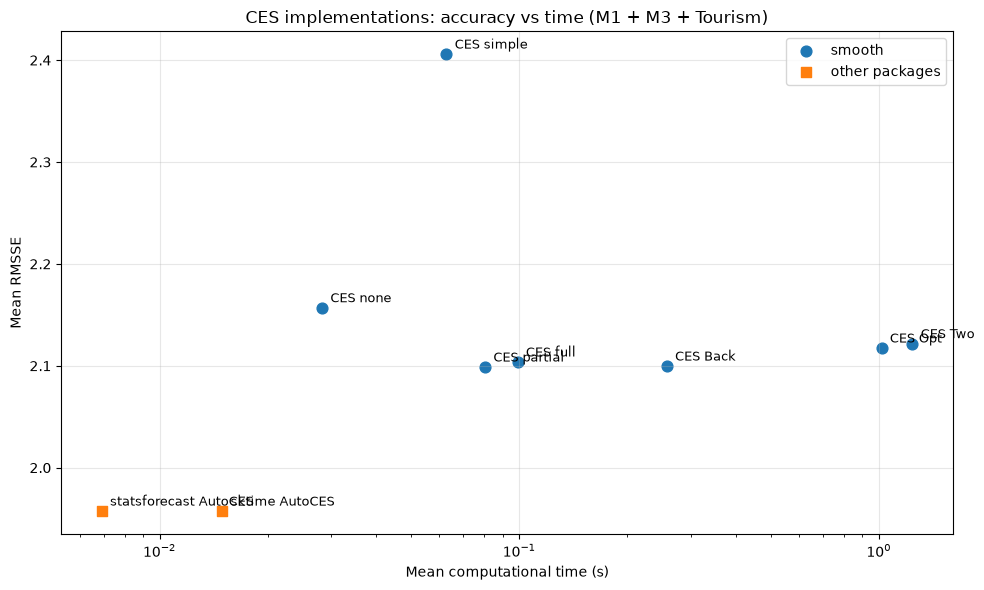

In [13]:
import matplotlib.pyplot as plt

x = np.array([np.nanmean(test_results[j, :, 2]) for j in range(methods_number)])
y = np.array([np.nanmean(test_results[j, :, 0]) for j in range(methods_number)])

fig, ax = plt.subplots(figsize=(10, 6))
is_smooth = np.array([not n.endswith('AutoCES') for n in methods_names])
ax.scatter(x[is_smooth], y[is_smooth], s=60, label='smooth')
ax.scatter(x[~is_smooth], y[~is_smooth], s=60, marker='s', label='other packages')
for xi, yi, name in zip(x, y, methods_names):
    ax.annotate(name, (xi, yi), textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set(xlabel='Mean computational time (s)', ylabel='Mean RMSSE',
       title='CES implementations: accuracy vs time (M1 + M3 + Tourism)')
ax.set_xscale('log')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Failed series diagnostics

In [14]:
series_ids = list(M1.keys()) + list(M3.keys()) + list(Tourism.keys())
dataset_sizes = {'M1': len(M1), 'M3': len(M3), 'Tourism': len(Tourism)}
dataset_boundaries = {}
offset = 0
for name, size in dataset_sizes.items():
    dataset_boundaries[name] = (offset, offset + size)
    offset += size

print("=" * 70)
print("FAILED SERIES DIAGNOSTICS")
print("=" * 70)

any_failures = False
for j, method in enumerate(methods_names):
    failed_mask = np.isnan(test_results[j, :, 0])
    n_failed = int(failed_mask.sum())
    if n_failed == 0:
        continue
    any_failures = True
    failed_indices = np.where(failed_mask)[0]
    print(f"\n{method} ({n_failed} failures):")
    for ds_name, (lo, hi) in dataset_boundaries.items():
        ds_failed = [series_ids[i] for i in failed_indices if lo <= i < hi]
        if ds_failed:
            print(f"  {ds_name}: {', '.join(str(s) for s in ds_failed[:40])}"
                  + (" ..." if len(ds_failed) > 40 else ""))

if not any_failures:
    print("\nNo failures detected.")

FAILED SERIES DIAGNOSTICS

No failures detected.
